# Exercise 02 - CNN

### Group members:

Elena Niero: 2200437

Eylül Çağla Ersöz: 2185017

Melissa Daniela de Almeida Nespeque: 2183904

Sahasra Sivakumar: 2183897

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14

import pandas as pd
from scipy import stats

import seaborn 
from sklearn import metrics

from sklearn.metrics import classification_report
from sklearn import preprocessing


import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.layers import GlobalMaxPooling1D
%run plot.py

In [ ]:
def Show_data(x,L,s="data"):
    plt.plot(np.arange(L),x[0])
    plt.plot(np.arange(L,2*L),x[1])
    plt.plot(np.arange(2*L,3*L),x[2])
    plt.title(s)
    plt.xlabel("time")
    plt.show()

In [ ]:
def Show_weights(model,l=0,label="model"):
    c=['r','y','c','b','m']
    m=['o','s','D','<','>']
    ms=10
    
    w = model.layers[l].get_weights()[0]
    
    print(w.shape)
    wT=w.T
    print(wT.shape)
    M=len(wT)
    b = model.layers[l].get_weights()[1] 
    
    fig,AX=plt.subplots(1,2,figsize=(12,4.4))
    ax=AX[0]
    ax.axhline(0, c="k")
    ax.plot((0,))
    for i in range(M):
        ax.plot(wT[i][0],"-",c=c[i],marker=m[i],label=str(i),markersize=ms)
    ax.set_title(label+': filters of layer '+str(l))
    ax.set_xlabel('index')
    ax=AX[1]
    ax.axhline(0, c="k")
    for i in range(M):
        ax.plot((i),(b[i]),c=c[i],marker=m[i],label="filter "+str(i),markersize=ms)
    ax.set_title(label+': bias of layer '+str(l))
    ax.set_xlabel('filter nr')
    ax.set_xticks(np.arange(5))
    ax.legend()
    plt.show()

In [ ]:
def Show_history(fit):
    fig,AX=plt.subplots(1,2,figsize=(12,5.))
    ax=AX[0] 
    ax.plot(fit.history['accuracy'],"b",label="train")
    ax.plot(fit.history['val_accuracy'],"r--",label="valid.")
    ax.plot((0,EPOCHS),(1/3,1/3),":",c="gray",label="random choice")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.set_ylim([0, 1])
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],"b",label="train")
    ax.plot(fit.history['val_loss'],"r--",label="valid.")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.set_ylim([0, 1.05*np.max(fit.history['loss'])])
    ax.legend()
    plt.show()

In [ ]:
LABELS = ["absent","positive","negative"] # from labels y 
cmap="GnBu"

def show_confusion_matrix(validations, predictions, label="Model"):

    matrix = metrics.confusion_matrix(validations, predictions)
    plt.figure(figsize=(6, 5))
    seaborn.heatmap(matrix,
                xticklabels=LABELS,
                yticklabels=LABELS,
                annot=True,
                fmt='d',
                linecolor='white',
                linewidths=1,
                cmap=cmap)
    plt.title(label+': Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

## Point 2: performances by varying the amplitude A

Incrementing A we expect the validation accuracy to increase as well. In fact, while the amplitude gets bigger the signal becomes more and more recognizable by the CNN.


>>> Running Experiment for Amplitude A = 50 (DX = 25)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final Validation Accuracy for A=50: 0.3465

>>> Running Experiment for Amplitude A = 100 (DX = 25)
Final Validation Accuracy for A=100: 0.3980

>>> Running Experiment for Amplitude A = 150 (DX = 25)
Final Validation Accuracy for A=150: 0.5000

>>> Running Experiment for Amplitude A = 200 (DX = 25)
Final Validation Accuracy for A=200: 0.6320

>>> Running Experiment for Amplitude A = 250 (DX = 25)
Final Validation Accuracy for A=250: 0.7345

>>> Running Experiment for Amplitude A = 300 (DX = 25)
Final Validation Accuracy for A=300: 0.7755

>>> Running Experiment for Amplitude A = 350 (DX = 25)
Final Validation Accuracy for A=350: 0.8540

>>> Running Experiment for Amplitude A = 400 (DX = 25)
Final Validation Accuracy for A=400: 0.8535

>>> Running Experiment for Amplitude A = 450 (DX = 25)
Final Validation Accuracy for A=450: 0.8695

>>> Running Experiment for Amplitude A = 500 (DX = 25)
Final Validation Accuracy for A=500: 0.9320

>>> Running Experiment for Amplitude A = 550 (DX = 25)
F

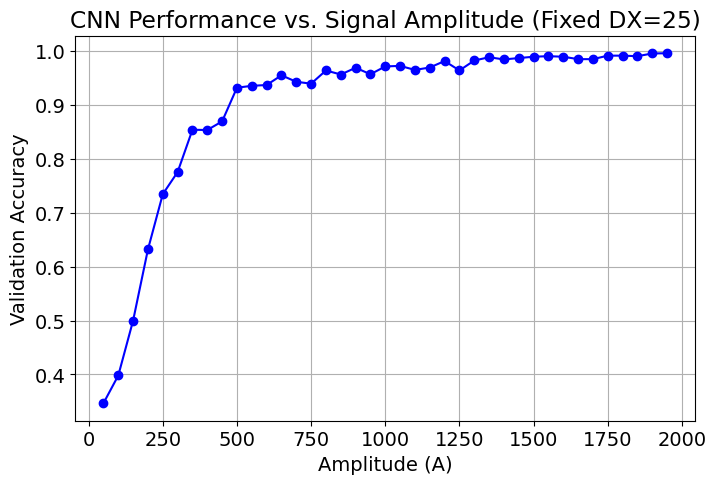

In [ ]:
DX = 25
Z = 12
N = 10000
L = 60
bias = 5
amplitudes=[]
for i in range(50,2000,50):
  amplitudes.append(i)

jump = lambda drift, stdev: int(np.random.normal(drift,stdev))
def pattern(i,z,a):
    return int(a*np.sin((np.pi*i)/z))
results = []

best_val_acc = 0
best_fit = None
best_model = None
best_A = 0
all_accuracies = []

for A in amplitudes:
    print(f"\n>>> Running Experiment for Amplitude A = {A} (DX = {DX})")

    y = [0] * N
    x = [[0] * L for i in range(N)]
    for i in range(N):
        if i > 0: x[i][0] = x[i-1][-1] + jump(bias, DX)
        for j in range(1, L):
            x[i][j] = x[i][j-1] + jump(bias, DX)

        y[i] = i % 3
        if y[i] > 0:
            j0 = np.random.randint(0, L-1-Z)
            sign = 3 - 2 * y[i]
            for j in range(Z):
                x[i][j0+j] += sign * pattern(j, Z, A)

    X_data = np.array(x)
    Y_data = tf.keras.utils.to_categorical(y, 3)


    xm = X_data.mean(axis=1)
    for i in range(N): X_data[i] = X_data[i] - xm[i]
    std = X_data.std(axis=1)
    for i in range(N): X_data[i] = X_data[i] / std[i]
    X_data = X_data.reshape(N, L, 1)

    perc_train = 0.8
    N_train = int(N * perc_train)
    x_train, x_val = X_data[:N_train], X_data[N_train:]
    y_train, y_val = Y_data[:N_train], Y_data[N_train:]
    reg = tf.keras.regularizers.l2(0.2)
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05,
                                        seed=None)

    model = Sequential()
    model.add(Conv1D(filters=5, kernel_size=11,
                     kernel_initializer=ini,
                     kernel_regularizer=reg,
                     activation='relu',
                     input_shape=(L,1)))
    model.add(AveragePooling1D(5))
    model.add(Conv1D(filters=5, kernel_size=7,
                     activation='relu'))
    model.add(Flatten())
    model.add(Dense(12, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(3, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    # Train
    fit = model.fit(x_train, y_train, epochs=10, batch_size=32,
                    validation_data=(x_val, y_val), verbose=0)

    final_acc = fit.history['val_accuracy'][-1]
    results.append(final_acc)
    print(f"Final Validation Accuracy for A={A}: {final_acc:.4f}")

    current_acc = fit.history['val_accuracy'][-1]
    all_accuracies.append(current_acc)

    # Track the best model
    if current_acc > best_val_acc:
        best_val_acc = current_acc
        best_fit = fit
        best_model = model
        best_A = A

print(f"\nBest Performance found at A = {best_A} with Accuracy = {best_val_acc:.4f}")
plt.figure(figsize=(8,5))
plt.plot(amplitudes, results, marker='o', linestyle='-', color='b')
plt.title("CNN Performance vs. Signal Amplitude (Fixed DX=25)")
plt.xlabel("Amplitude (A)")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.show()

## Point 3: performances by varying lambda

## Point 4: a different model (optional)

Now we try a different model of our CNN. We implemented 3 convolutional layers, followed by a global max pooling (which will keep just the most significant local feature). Here is our schema:

### Read, split and rescale

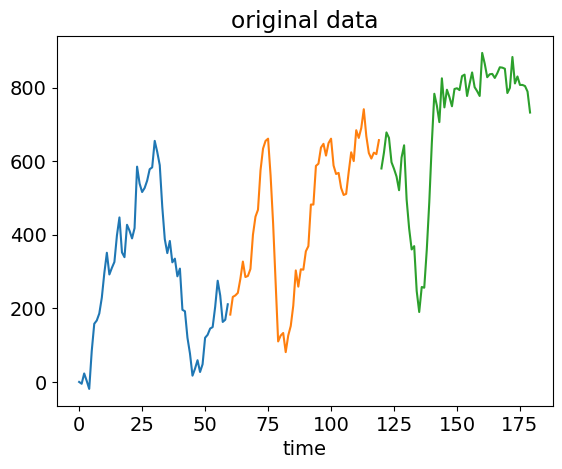

data:  10000


In [6]:
str0 = 'ts_L60_Z12_A500_DX50_bias5_N10000.dat'
fnamex='DATA/x_'+str0
fnamey='DATA/y_'+str0

x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
# number of samples, number of features
N,L = len(x), len(x[0])

Show_data(x,L,"original data")

categ = np.loadtxt(fnamey, dtype=int)
n_class = 3    # y.argmax() - y.argmin() +1
print('data: ',N)

y = np.zeros((N,n_class))
for i in range(N):
    y[i][categ[i]] = 1. # y contains one-hot encoding

In [ ]:
# split into training and validation sets
perc_train=0.8
N_train = int(perc_train*N)
x_train = x[:N_train]
print(x_train.shape)
y_train = y[:N_train]
x_val = x[N_train:]
y_val = y[N_train:]
N_val = len(x_val)
print('N_train=',N_train,'  N_val=',N_val,'  L=',L,'  n_class=',n_class)

#remove average value of each sample from its values
xm_train = x_train.mean(axis=1)
std_train = x_train.std(axis=1)
xm_val = x_val.mean(axis=1)
std_val = x_val.std(axis=1)
print('std_train average and mean:',max(std_train), min(std_train), std_train.mean(axis=0))
print('std_val average and mean:',max(std_val), min(std_val), std_val.mean(axis=0))

# rescale with variance on the training set
for i in range(N_train):
     x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
for i in range(N_val):
    x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)

# Keras wants an additional dimension with a 1 at the end
x_train = x_train.reshape(x_train.shape[0], L, 1)
x_val =  x_val.reshape(x_val.shape[0], L, 1)
input_shape = (L, 1) # number of features, number of channels (1 for 1D data)

(8000, 60)
N_train= 8000   N_val= 2000   L= 60   n_class= 3
std_train average and mean: 588.25397835931 44.84287073276593 201.46657645528722
std_val average and mean: 569.9090424503428 55.06717110341998 201.92178219610327


### New model

In [ ]:
np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)

reg = tf.keras.regularizers.l2(0.2) 
ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, 
                                        seed=None)

NF = 6 

model = Sequential()
model.add(Conv1D(filters=NF, kernel_size= 3, 
                kernel_initializer=ini, 
                kernel_regularizer=reg,
                activation='relu', 
                input_shape=input_shape)) 
model.add(Conv1D(filters=8, kernel_size=9, 
                activation='relu'))
model.add(Conv1D(filters=4, kernel_size=3, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(n_class, activation='softmax')) 
print(model.summary())

opt = tf.keras.optimizers.Adam()

model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=opt,metrics=['accuracy'])

/home/elena_niero/anaconda3/envs/nn_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773843566.758526  582198 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 6)          │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 8)          │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 48, 4)          │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 4)              │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 579 (2.26 KB)

 Trainable params: 579 (2.26 KB)

 Non-trainable params: 0 (0.00 B)

None


### Fit and results

In [ ]:
# ...LESSON ...
# Hyper-parameters
# with small minibatch it does not converge!! 
BATCH_SIZE = 200
EPOCHS = 150

#print('----- Model ',NCONV,'-----\nFITTING....')
fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(x_val, y_val),
                verbose=2, shuffle=True) 

Epoch 1/150
40/40 - 1s - 21ms/step - accuracy: 0.4291 - loss: 1.0874 - val_accuracy: 0.4000 - val_loss: 1.0660
Epoch 2/150
40/40 - 0s - 3ms/step - accuracy: 0.5459 - loss: 1.0112 - val_accuracy: 0.6030 - val_loss: 0.9367
Epoch 3/150
40/40 - 0s - 3ms/step - accuracy: 0.7013 - loss: 0.8269 - val_accuracy: 0.7805 - val_loss: 0.7379
Epoch 4/150
40/40 - 0s - 3ms/step - accuracy: 0.8246 - loss: 0.6572 - val_accuracy: 0.8455 - val_loss: 0.6143
Epoch 5/150
40/40 - 0s - 3ms/step - accuracy: 0.8589 - loss: 0.5598 - val_accuracy: 0.8660 - val_loss: 0.5464
Epoch 6/150
40/40 - 0s - 4ms/step - accuracy: 0.8695 - loss: 0.5030 - val_accuracy: 0.8670 - val_loss: 0.5038
Epoch 7/150
40/40 - 0s - 4ms/step - accuracy: 0.8764 - loss: 0.4652 - val_accuracy: 0.8715 - val_loss: 0.4721
Epoch 8/150
40/40 - 0s - 4ms/step - accuracy: 0.8849 - loss: 0.4355 - val_accuracy: 0.8805 - val_loss: 0.4439
Epoch 9/150
40/40 - 0s - 4ms/step - accuracy: 0.8903 - loss: 0.4083 - val_accuracy: 0.8885 - val_loss: 0.4171
Epoch 10/

Validation accuracy =  0.9890000224113464


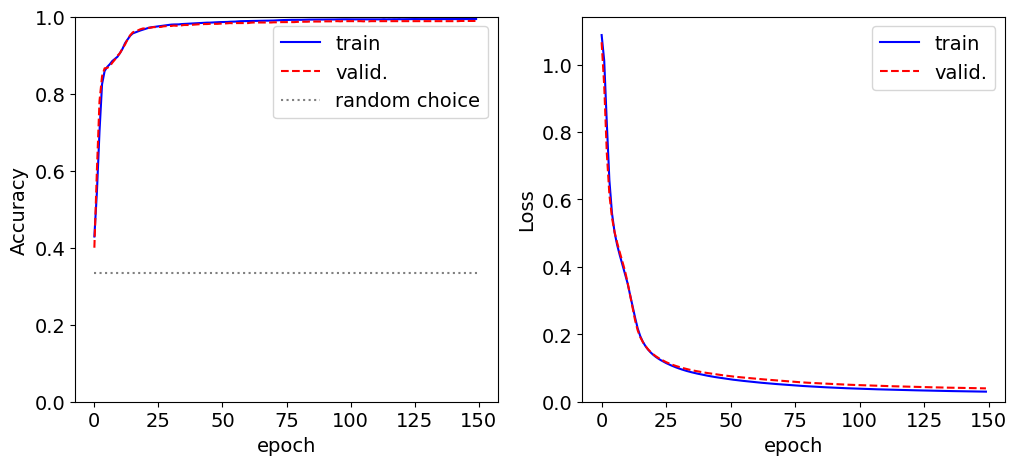

(3, 8, 4)
(4, 8, 3)


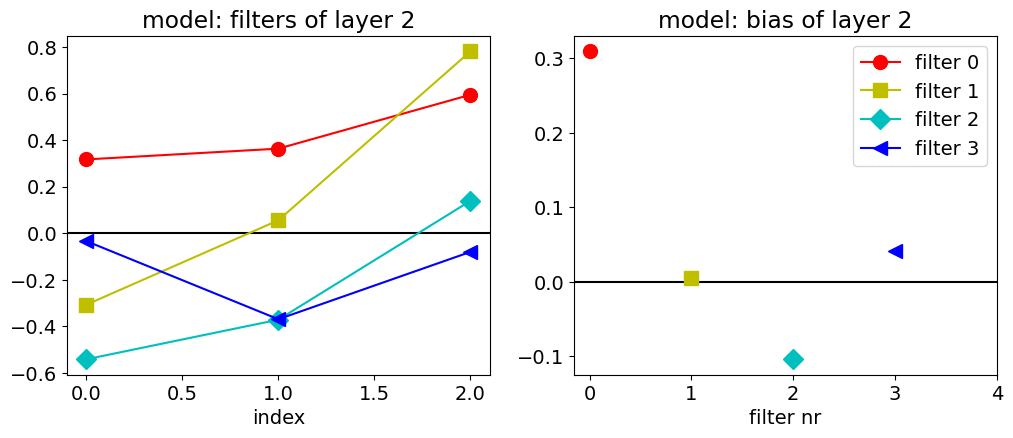

In [ ]:
print("Validation accuracy = ", fit.history['val_accuracy'][-1])
Show_history(fit)

Show_weights(model,2)

### Confusion matrix

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


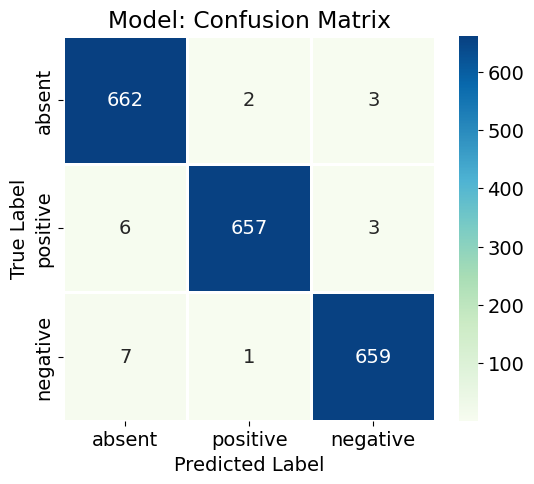

In [ ]:
y_pred_val = model.predict(x_val)

max_y_pred_val = np.argmax(y_pred_val, axis=1)
max_y_val = np.argmax(y_val, axis=1)

show_confusion_matrix(max_y_val, max_y_pred_val)